
This notebook walks through the core concepts of Bitcoin by building a minimal blockchain
in Python. We cover three major areas of cryptography and how they fit together:

| Category | Algorithm | Role in Bitcoin |
|----------|-----------|------------------|
| **Hashing** | SHA-256 | One-way fingerprints for blocks, transactions, mining |
| **Asymmetric Crypto** | ECDSA (secp256k1) | Public/private key pairs for identities & signing |
| **Symmetric Crypto** | AES, etc. | Used in wallets, not in the core protocol |

## Key Concepts

- **UTXO Model:** Bitcoin doesn't use accounts/balances. It uses Unspent Transaction Outputs (UTXOs),
  like individual cash bills. Your "balance" is the sum of all UTXOs your keys can unlock.
- **Digital Signatures:** Prove you own a UTXO without revealing your private key.
- **Proof of Work:** Miners brute-force a `nonce` until the block's hash starts with enough zeros.
- **Chain Linking:** Each block includes the previous block's hash, making tampering evident.

## 1. Cryptographic Hashing with SHA-256

### Hashing vs. Python's built-in `hash()`

Python's `hash()` uses **SipHash-1-3** — a fast, non-cryptographic hash designed for
dictionary lookups. It's:
- Randomized per session (to prevent HashDoS attacks)
- NOT collision-resistant or suitable for security

Bitcoin needs **SHA-256** — deterministic, collision-resistant, and one-way.

SHA-256 isn't used to *hide* data — it's used as a **fingerprint**. Given a hash,
you can never work backwards to the original input. But given an input, you'll
always get the same hash. With $2^{256}$ possible outputs, accidental collisions
are essentially impossible.

In [1]:
import hashlib

# SHA-256 takes bytes and returns a 64-char hex string.
# Same input -> same output, every time.
hashlib.sha256(b'123').hexdigest()

'a665a45920422f9d417e4867efdc4fb8a04a1f3fff1fa07e998e86f7f7a27ae3'

In [2]:
# A helper: .digest() returns raw bytes (not hex), which is what secp256k1 expects.
def hash_fn(msg): return hashlib.sha256(msg).digest()

## 2. Elliptic Curve Cryptography (ECC)

### What is ECC?

Elliptic Curve Cryptography builds on the math of elliptic curves — curves defined by:

$$y^2 = x^3 + ax + b$$

Bitcoin uses the **SECP256k1** curve where $a=0, b=7$:

$$y^2 = x^3 + 7$$

The **hard problem**: given a starting point $G$ (the Generator), your private key is
a big random number $k$, and your public key is $k \times G$ (point on the curve).
Computing $k \times G$ is easy, but reversing it (finding $k$ from the public key)
is computationally impossible with a 256-bit key.

### Why not RSA? (And why ECC wins)

The most common public-key system before ECC was **RSA** (Rivest–Shamir–Adleman, 1977),
still widely used in TLS/HTTPS, email encryption, and digital certificates. RSA's security
relies on the **integer factorization problem**: given two large primes $p$ and $q$, it's
easy to compute their product $n = p \times q$, but given $n$ alone, factoring it back
into $p$ and $q$ is computationally infeasible for large keys.

- **Public key:** $(n, e)$ — used to encrypt or verify
- **Private key:** $(n, d)$ — used to decrypt or sign

RSA works, but it has a problem. Factoring is vulnerable to sub-exponential algorithms
like the General Number Field Sieve — attacks smarter than brute force. To compensate,
RSA key sizes must keep growing: 2048-bit is the bare minimum today, 3072+ recommended.

Other systems (DSA, Diffie-Hellman, ElGamal) have the same weakness — they all need
large keys. This is what makes ECC special: the elliptic curve discrete logarithm problem
has **no known sub-exponential attack**. It's fundamentally harder per bit:

| Security Level | RSA Key Size | ECC Key Size |
|----------------|-------------|--------------|
| 128-bit | 3072 bits   | **256 bits** |
| 192-bit | 7680 bits   | **384 bits** |
| 256-bit | 15360 bits  | **521 bits** |

A 256-bit ECC key provides security equivalent to a ~3072-bit RSA key — that's over
**10x smaller** for the same security. For Bitcoin, this matters enormously:

- **Smaller signatures & keys** → less data per transaction → lower fees
- **Faster verification** → nodes can validate blocks more quickly
- **Less storage & bandwidth** → critical for a global decentralized network with
  thousands of nodes

In short: RSA works, but ECC gives you the same (or better) security in a fraction
of the size. For a blockchain where every byte counts, that's a big deal.

### Further Reading
- **ECC:** [Cloudflare's Primer on ECC](https://blog.cloudflare.com/a-relatively-easy-to-understand-primer-on-elliptic-curve-cryptography/) · [Wikipedia: Elliptic-curve cryptography](https://en.wikipedia.org/wiki/Elliptic-curve_cryptography)
- **RSA:** [Brilliant: RSA Encryption](https://brilliant.org/wiki/rsa-encryption/) · [Wikipedia: RSA cryptosystem](https://en.wikipedia.org/wiki/RSA_cryptosystem) · [CrypTool: RSA step-by-step](https://www.cryptool.org/en/cto/rsa-step-by-step/)

Below, we'll first understand *why* Bitcoin uses these curves, and then visualize them — first over the real numbers (smooth), then over a finite field (discrete points).

### What Do Elliptic Curves Actually Achieve?

Before we look at the curves visually, it helps to understand *why* Bitcoin uses them at all.

**The core problem:** Alice wants to prove she owns some bitcoin, without revealing her secret (private key). She needs a math operation that's:

- **Easy to do forward:** take a number, multiply it by a point on the curve → get a new point
- **Impossible to reverse:** given that new point, figure out the original number

Elliptic curves give us exactly this. Your **private key** is just a big random number $k$. Your **public key** is that number multiplied by the generator point $G$ on the curve: $K = k \times G$. Anyone can verify your signature using the public key, but no one can work backwards to find $k$.

**Why curves specifically?** Because point multiplication on an elliptic curve is the hardest one-way function we know of per bit of key size — harder than RSA's factoring problem. Think of it like mixing paint: easy to blend two colors together, but nearly impossible to look at the result and figure out exactly which two colors were used.

With the *why* established, let's talk about what to look for in the diagrams.

**Lets look at the Elliptical curves for intuition** The diagrams below aren't security proofs — they're intuition for two things that matter later:

1. **Symmetry**: for every point $(x, y)$ there's a matching $(x, -y)$. This is why Bitcoin can compress a public key to just the $x$-coordinate plus a single parity bit — saving ~50% space on every transaction.

2. **Discrete points**: Bitcoin doesn't use the smooth curve — it uses a finite field (mod a prime $p$). All the point addition and multiplication still works, but on a scattered cloud of discrete points. The smooth curve is just for intuition.

With that in mind, here's what they look like:

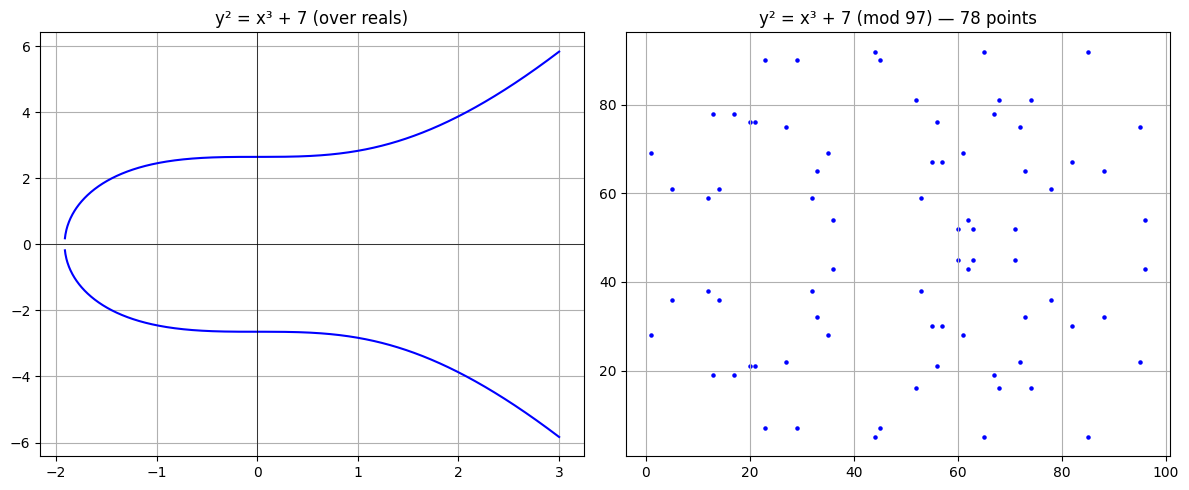

Notice the symmetry: for every (x, y), the point (x, -y) also exists.
This is why we only need to store x + a parity bit to compress a public key.


In [ ]:
#| code-fold: True
import numpy as np
import matplotlib.pyplot as plt

# --- Smooth curve (over real numbers, for intuition) ---
x = np.linspace(-2, 3, 1000)
y_sq = x**3 + 7
mask = y_sq >= 0
x = x[mask]
y_pos = np.sqrt(x**3 + 7)
y_neg = -y_pos

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(x, y_pos, 'b')
ax1.plot(x, y_neg, 'b')
ax1.axhline(0, color='k', linewidth=0.5)
ax1.axvline(0, color='k', linewidth=0.5)
ax1.set_title('y² = x³ + 7 (over reals)')
ax1.grid(True)

# --- Finite field (mod 97, for visualization) ---
p = 97  # small prime for visualization (Bitcoin uses a 256-bit prime)
points = []
for xf in range(p):
    for yf in range(p):
        if (yf*yf - xf**3 - 7) % p == 0:
            points.append((xf, yf))

xs, ys = zip(*points)
ax2.scatter(xs, ys, s=5, color='blue')
ax2.set_title(f'y² = x³ + 7 (mod {p}) — {len(points)} points')
ax2.grid(True)

plt.tight_layout()
plt.show()

print("Notice the symmetry: for every (x, y), the point (x, -y) also exists.")
print("This is why we only need to store x + a parity bit to compress a public key.")

### Public Key Compression

Since $y^2 = x^3 + 7$, given $x$ there are only two possible $y$ values (one even, one odd).
So a public key can be compressed from 65 bytes (full $x, y$) down to **33 bytes**:
just the full $x$ coordinate + a prefix byte (`02` = even $y$, `03` = odd $y$).

### Address Generation Pipeline

```
private key (32 bytes)
    ↓  ECC multiplication
compressed public key (33 bytes)
    ↓  SHA256 → RIPEMD160
address hash (20 bytes)
    ↓  Base58Check encoding
Bitcoin address (e.g. 1A1zP1...)
```

## 3. Key Generation

We use the `secp256k1` library to generate a real key pair. The private key is 32
random bytes; the public key is the point $k \times G$ on the curve.

In [4]:
import os
import secp256k1

def get_account():
    """Generate a random private key and derive the public key.
    Returns (PrivateKey, PublicKey) objects from the secp256k1 library."""
    private_key = secp256k1.PrivateKey(os.urandom(32))
    return private_key, private_key.pubkey

## 4. Digital Signatures — Signing and Verifying

A digital signature proves ownership of a private key *without revealing it*.

### How it works
1. **Signing (sender):** Hash the message, then combine the hash + private key using
   ECDSA to produce a signature.
2. **Verifying (miner/anyone):** Feed the message hash + signature + public key into
   the verification algorithm. Returns `True` if valid.

### Properties
- **Proof of Ownership:** Only the private key holder could have produced the signature.
- **Tamper-Proof:** Changing even one character in the message invalidates the signature.

### Note on the math
We don't just hash(private_key + message). That would require the verifier to know
the private key. Instead, ECDSA creates a mathematical puzzle that can be *verified*
with just the public key, but only *solved* with the private key.

In [5]:
# Step 1: Create and hash a message
msg = b'Send 1 satoshi to Bob'
msg_hash = hash_fn(msg)

# Step 2: Generate a key pair
priv_key, pub_key = get_account()

# Step 3: Sign the hash with the private key
# The signature is 64 bytes, mathematically tied to both the message and private key.
signature = priv_key.ecdsa_sign(msg_hash)

# Step 4: Verify using the public key (anyone can do this)
is_valid = pub_key.ecdsa_verify(msg_hash, signature)
print(f"Signature valid: {is_valid}")

# Step 5: Tamper with the message — signature should fail
tampered_msg = b'Send 10 satoshi to Bob'  # 1 satoshi -> 10 satoshis
tampered_hash = hash_fn(tampered_msg)
is_valid_tampered = pub_key.ecdsa_verify(tampered_hash, signature)
print(f"Tampered signature valid: {is_valid_tampered}")

Signature valid: True
Tampered signature valid: False


## 5. The UTXO Model and Transactions

### UTXO = Unspent Transaction Output

Bitcoin doesn't track "accounts" with balances. Instead, it tracks individual UTXOs —
like cash bills. If you have a $20 bill and buy a $5 coffee:
- Your $20 UTXO is **consumed** as an input
- Two new UTXOs are **created** as outputs: $5 to the shop, $15 change back to you

Your "balance" = sum of all UTXOs your private key can unlock.

### Spending multiple UTXOs

A transaction can have **multiple inputs** — just like pulling three $5 bills from
your wallet to pay for a $12 item. Each input needs its own signature.

In [6]:
from fastcore.all import *

class UTXO:
    """An Unspent Transaction Output.
    - amount:   value in satoshis
    - pub_key:  the secp256k1.PublicKey that can spend this UTXO
    - spent:    whether this UTXO has been consumed by a transaction
    """
    def __init__(self, amount, pub_key, spent=False):
        store_attr()

In [7]:
class Transaction:
    """A Bitcoin-style transaction.
    - inputs:   list of UTXOs being consumed (must be unspent)
    - outputs:  list of new UTXOs being created
    - signatures: list of ECDSA signatures, one per input
    """
    def __init__(self, inputs, outputs):
        self.inputs  = inputs   # UTXOs we are spending
        self.outputs = outputs  # New UTXOs being created

    def validate_input(self):
        """Check that total inputs >= total outputs (you can't spend more than you have)."""
        input_amount  = sum(o.amount for o in self.inputs)
        output_amount = sum(o.amount for o in self.outputs)
        if input_amount >= output_amount: return True
        return False

    def transact(self):
        """Process the transaction: validate math and mark inputs as spent."""
        if not self.validate_input(): return f'Invalid transaction'
        for o in self.inputs: o.spent = True

    def get_hash(self, input_index):
        """Hash the transaction data for a specific input.
        The input_index ensures each input signs a slightly different hash,
        preventing replay attacks (same concept as real Bitcoin)."""
        tx_data = f"In:{[o.amount for o in self.inputs]} Out:{[o.amount for o in self.outputs]}; this is {input_index}"
        return hash_fn(tx_data.encode())

    def sign_input(self, input_index, priv_key):
        """Sign a specific input with the given private key.
        Each input gets its own signature — the wallet does this automatically."""
        if not hasattr(self, 'signatures'):
            self.signatures = [None] * len(self.inputs)
        self.signatures[input_index] = priv_key.ecdsa_sign(self.get_hash(input_index))

    def verify(self):
        """Verify all signatures. Each input's signature must be valid against
        the corresponding UTXO's public key."""
        return all(
            inp.pub_key.ecdsa_verify(self.get_hash(idx), sig)
            for idx, (inp, sig) in enumerate(zip(self.inputs, self.signatures))
        )

### Putting it together: Alice sends Bitcoin to Bob

Alice has two UTXOs (50 + 30 = 80 satoshis). She sends 70 to Bob and keeps 10 as change.
She signs each input, then we verify the whole transaction is authentic.

In [8]:
# 1. Generate keys for Alice and Bob
alice_priv, alice_pub = get_account()
bob_priv,   bob_pub   = get_account()

# 2. Create Alice's UTXOs (she owns these from previous transactions)
utxo1 = UTXO(amount=50, pub_key=alice_pub)
utxo2 = UTXO(amount=30, pub_key=alice_pub)

# 3. Build the transaction:
#    Inputs:  50 + 30 = 80 satoshis from Alice
#    Outputs: 70 to Bob, 10 change to Alice
tx = Transaction(
    inputs=[utxo1, utxo2],
    outputs=[UTXO(amount=70, pub_key=bob_pub), UTXO(amount=10, pub_key=alice_pub)]
)

# 4. Alice signs each input (wallet does this automatically in practice)
tx.sign_input(0, alice_priv)
tx.sign_input(1, alice_priv)

# 5. Verify — miners do this before including the transaction in a block
print(f"Transaction valid: {tx.verify()}")

# 6. Process the transaction — mark old UTXOs as spent
tx.transact()
print(f"Inputs spent:     {[u.spent for u in tx.inputs]}")

Transaction valid: True
Inputs spent:     [True, True]


## 6. Blocks and Proof-of-Work Mining

### What is a Block?

A block is a container for transactions, plus metadata that links it to the chain:
- **transactions**: list of confirmed transactions
- **prev_block_hash**: hash of the previous block (creates the "chain")
- **nonce**: the number miners brute-force to find a valid hash

### How Mining Works

Miners repeatedly hash the block while incrementing the `nonce`, looking for a hash
that starts with a target number of zeros. This is **Proof of Work**:
- **Hard to find**: millions of guesses required
- **Easy to verify**: anyone can hash once and check
- **Difficulty** = number of leading zeros required

The first miner to find a valid nonce broadcasts the block. The network verifies it,
and the block is added to the chain. The miner earns a block reward + transaction fees.

In [9]:
class Block:
    """A single block in the blockchain.
    - transactions:      list of Transaction objects in this block
    - prev_block_hash:   hex string linking to the previous block
    - nonce:             number used once — miners increment this to find a valid hash
    """
    def __init__(self, transactions, prev_block_hash, nonce=0):
        store_attr()

    def create_hash(self):
        """Hash the block contents: previous hash + transaction data + nonce."""
        trans_str = self.prev_block_hash
        for o in self.transactions: trans_str += str(o)
        trans_str += str(self.nonce)
        return hash_fn(trans_str.encode())

    def mine(self, difficulty: int = 2):
        """Brute-force the nonce until create_hash() starts with `difficulty` zeros.
        difficulty=4 means we need a hash starting with '0000'."""
        target = '0' * difficulty
        while not self.create_hash().hex().startswith(target):
            self.nonce += 1
        print(f"Mined block! Nonce: {self.nonce}")
        print(f"Hash:   {self.create_hash().hex()}")

### The Genesis Block

The very first block in a blockchain. Its `prev_block_hash` is all zeros because
there's nothing before it. (Bitcoin's real genesis block was mined by Satoshi Nakamoto
on January 3, 2009.)

In [10]:
# The genesis block contains our Alice->Bob transaction.
# Its prev_block_hash is all zeros (nothing came before it).
genesis_block = Block(
    transactions=[tx],
    prev_block_hash="0" * 64
)

# Mine it! Higher difficulty = more leading zeros = much longer to compute.
# Try difficulty=2 first, then bump to 4 or 5 to see the difference.
genesis_block.mine(difficulty=4)

Mined block! Nonce: 60699
Hash:   0000599ce1c15af69c019c9b8563475beaeef688a6ced5923fa728edb833a551


## 7. The Blockchain

A `Blockchain` stores the chain and enforces linking: each new block must point
to the current chain tip via its `prev_block_hash`.

### Fork Resolution

When two miners find a valid block at almost the same time, the chain temporarily
forks. The network resolves this by always following the **longest chain** (most
cumulative work). The tie is broken when the next block is mined on one branch,
and the other branch becomes an "orphan" that's abandoned.

In [11]:
class Blockchain:
    """A simple blockchain that stores blocks and enforces hash linking."""
    def __init__(self):
        self.chain = []
        self.prev_block_hash = "0" * 64  # genesis prev hash

    def add_block(self, block):
        """Add a block only if its prev_block_hash matches the current chain tip."""
        if block.prev_block_hash != self.prev_block_hash: return False
        self.chain.append(block)
        self.prev_block_hash = self.chain[-1].create_hash().hex()

In [12]:
# 1. Initialize the blockchain
my_chain = Blockchain()

# 2. Add the genesis block (already mined above)
my_chain.add_block(genesis_block)
print(f"Chain length after genesis: {len(my_chain.chain)}")

# 3. Mine and add a second block
# Note: it links to the genesis block via my_chain.prev_block_hash
block_2 = Block(
    transactions=[],  # empty for simplicity
    prev_block_hash=my_chain.prev_block_hash
)

print("\nMining block 2...")
block_2.mine(difficulty=4)

my_chain.add_block(block_2)
print(f"\nChain length after block 2: {len(my_chain.chain)}")

Chain length after genesis: 1

Mining block 2...
Mined block! Nonce: 25841
Hash:   0000cc9875df0e8b172014556622fcf8a37289eafb7a5afe518c587c955852d2

Chain length after block 2: 2


## Summary: The Logical Flow of a Bitcoin Transaction

```
1. IDENTITIES     Alice & Bob generate private/public key pairs (secp256k1)
       ↓
2. TRANSACTION    Alice takes her UTXOs, signs them with her private key,
                  creates new UTXOs locked to Bob's public key
       ↓
3. BROADCAST      Transaction is sent to the network (mempool)
       ↓
4. BLOCK          Miner packages transactions into a block, verifies signatures
       ↓
5. MINING         Miner brute-forces the nonce until SHA-256 hash starts
                  with enough zeros (Proof of Work)
       ↓
6. CHAIN          Block is added. Old UTXOs are spent, new UTXOs are live.
                  If two miners find a block simultaneously, the longest
                  chain wins (fork resolution).
```

### What we built

| Component | Class/Function | What it does |
|-----------|---------------|--------------|
| Hashing | `hash_fn()` | SHA-256 hash returning raw bytes |
| Keys | `get_account()` | Generate secp256k1 private/public key pair |
| UTXO | `UTXO` | Unspent Transaction Output with amount, pub_key, spent status |
| Transaction | `Transaction` | Groups inputs/outputs, handles signing & verification |
| Block | `Block` | Holds transactions, links to previous block, mines with Proof of Work |
| Blockchain | `Blockchain` | Stores the chain, enforces hash linking between blocks |

## 8. What Else Could We Build?

This is just the foundation. Here are natural next steps, roughly in order of complexity:

### Near-term extensions
- **Merkle Trees** — Instead of hashing transactions individually, Bitcoin hashes them into a binary tree. This lets you prove a transaction is in a block without downloading the whole block (SPV / "light clients").
- **Transaction Fees** — The difference between inputs and outputs isn't wasted — it goes to the miner. We already allow `input > output`; we'd just need to track and award that difference.
- **Coinbase Transactions** — Each block contains a special first transaction that creates new coins out of nowhere (the block reward). This is how new Bitcoin enters circulation.
- **Difficulty Adjustment** — Real Bitcoin adjusts difficulty every 2016 blocks (~2 weeks) to keep block time at ~10 minutes, regardless of total network hashpower.

### Medium-term extensions
- **Networking / P2P** — Nodes that discover peers, gossip transactions, and propagate blocks. Even a simple simulated network would illustrate consensus.
- **Wallet with Address Derivation** — Hash the public key through SHA-256 → RIPEMD-160 → Base58Check to produce real-looking Bitcoin addresses.
- **Script / Locking Conditions** — Bitcoin transactions use a small stack-based scripting language. The simplest case is "must provide a signature matching this public key," but it supports multisig, timelocks, and more.
- **Mempool & Block Templates** — A pool of unconfirmed transactions that miners select from, prioritizing higher fees.

### Advanced
- **SegWit / Witness Data** — Separating signatures from the transaction data that gets hashed, fixing transaction malleability.
- **SPV Verification** — A lightweight client that verifies transactions using Merkle proofs without downloading the full blockchain.
- **Simple Payment Verification vs. Full Nodes** — Tradeoffs between trust, storage, and verification.
- **Double-spend detection** — Rejected conflicting transactions that try to spend the same UTXO twice.